# Boosting

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("../data/전처리완료.csv")

In [7]:
# 데이터 분리 라이브러리
from sklearn.model_selection import train_test_split

# 특징 변수(X)와 목표 변수(y) 분리
X = df.drop('고객이탈여부', axis=1)
y = df['고객이탈여부']

# 학습 데이터와 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 1. AdaBoost

In [8]:
# 필요한 라이브러리 불러오기
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 약한 학습자로 사용할 의사결정 나무 모델
base_estimator = DecisionTreeClassifier(max_depth=1)

# AdaBoostClassifier 모델 초기화
ada = AdaBoostClassifier(base_estimator=base_estimator, n_estimators=50, learning_rate=1.0, random_state=42)

# 모델 학습
ada.fit(X_train, y_train)

# 예측
y_pred_ada = ada.predict(X_test)

# 정확도 출력
accuracy = accuracy_score(y_test, y_pred_ada)
print(f"AdaBoost 모델의 정확도: {accuracy:.2f}")

AdaBoost 모델의 정확도: 0.85


In [9]:
# 성과평가 라이브러리 불러오기
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import roc_curve, roc_auc_score

# 평가
print("Accuracy:", accuracy_score(y_test, y_pred_ada))
print("Precision:", precision_score(y_test, y_pred_ada))
print("Recall", recall_score(y_test, y_pred_ada))
print("f1_score", f1_score(y_test, y_pred_ada))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_ada))
print("Classification Report:\n", classification_report(y_test, y_pred_ada))

Accuracy: 0.853
Precision: 0.6787003610108303
Recall 0.47837150127226463
f1_score 0.5611940298507463
Confusion Matrix:
 [[1518   89]
 [ 205  188]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.94      0.91      1607
           1       0.68      0.48      0.56       393

    accuracy                           0.85      2000
   macro avg       0.78      0.71      0.74      2000
weighted avg       0.84      0.85      0.84      2000



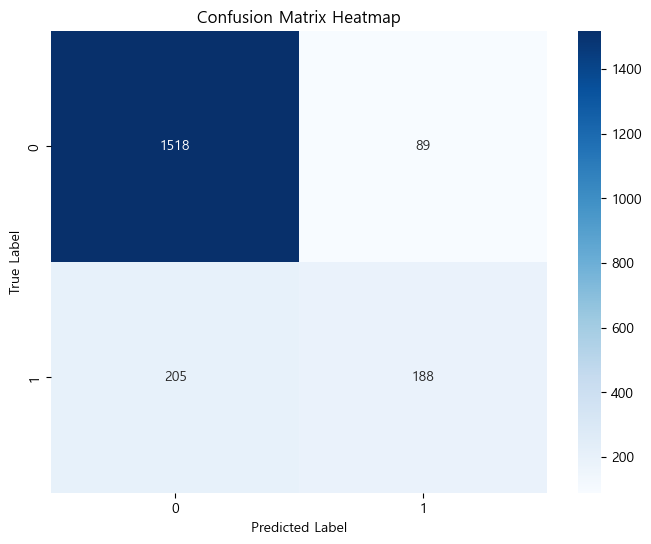

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
# 히트맵 시각화
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred_ada), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

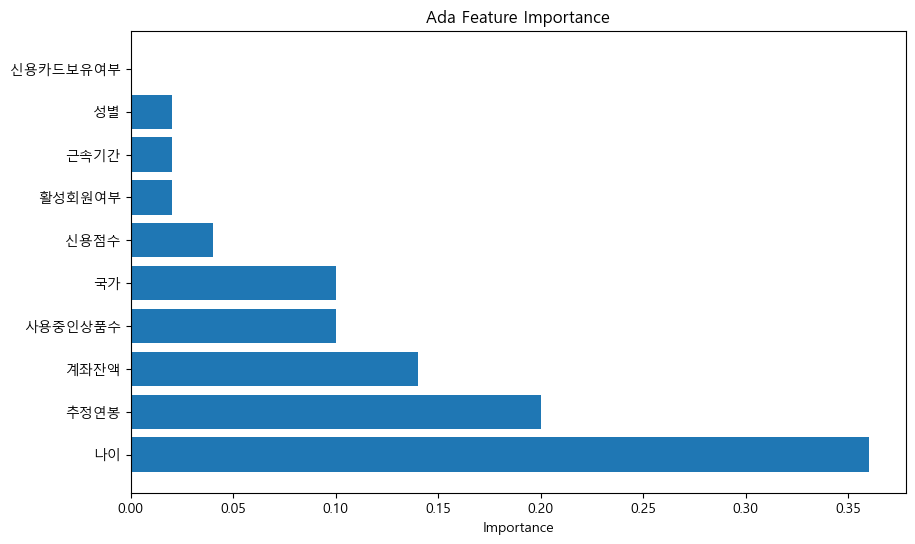

In [25]:
# 피처 중요도 출력
feature_importances = ada.feature_importances_
indices = np.argsort(feature_importances)[::-1]

# 특성 중요도 시각화
plt.figure(figsize=(10, 6))
plt.title('Ada Feature Importance')
plt.barh(range(X.shape[1]), feature_importances[indices], align='center')
plt.yticks(range(X.shape[1]), np.array(X.columns)[indices])
plt.xlabel('Importance')
plt.show()

### 2.  Gradient Boosting Machine (GBM)


GBM 모델의 정확도: 0.87
피처 중요도: [0.01952041 0.03511342 0.014764   0.39440226 0.00511274 0.06862273
 0.31621911 0.00068104 0.1214389  0.02412539]
Accuracy: 0.8655
Precision: 0.7540983606557377
Recall 0.4681933842239186
f1_score 0.5777080062794349
Confusion Matrix:
 [[1547   60]
 [ 209  184]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.47      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000



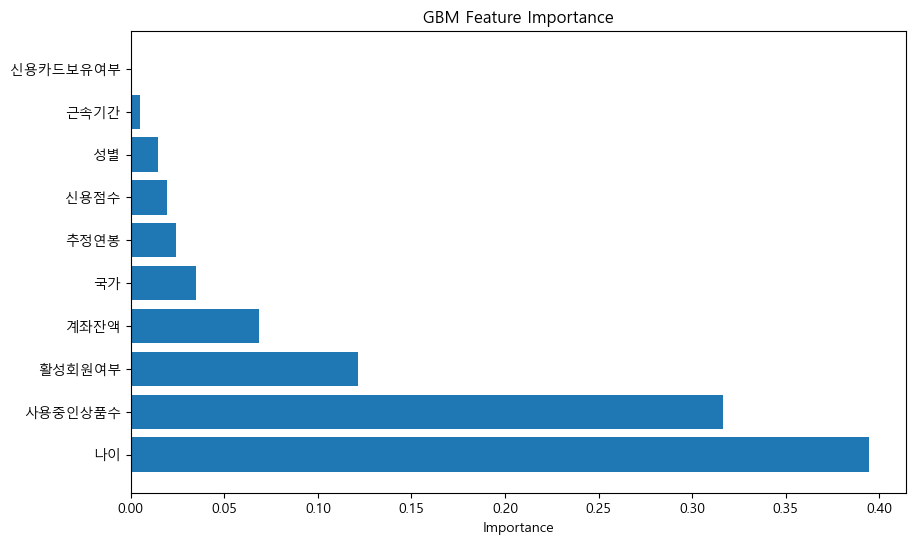

In [26]:

from sklearn.ensemble import GradientBoostingClassifier

# GradientBoostingClassifier 모델 초기화
gbm = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# 모델 학습
gbm.fit(X_train, y_train)

# 예측
y_pred_gbm = gbm.predict(X_test)

# 정확도 출력
accuracy = accuracy_score(y_test, y_pred_gbm)
print(f"GBM 모델의 정확도: {accuracy:.2f}")

# 피처 중요도 출력
feature_importances = gbm.feature_importances_
print("피처 중요도:", feature_importances)

# 평가
print("Accuracy:", accuracy_score(y_test, y_pred_gbm))
print("Precision:", precision_score(y_test, y_pred_gbm))
print("Recall", recall_score(y_test, y_pred_gbm))
print("f1_score", f1_score(y_test, y_pred_gbm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_gbm))
print("Classification Report:\n", classification_report(y_test, y_pred_gbm))

# 피처 중요도 출력
feature_importances = gbm.feature_importances_
indices = np.argsort(feature_importances)[::-1]

# 특성 중요도 시각화
plt.figure(figsize=(10, 6))
plt.title('GBM Feature Importance')
plt.barh(range(X.shape[1]), feature_importances[indices], align='center')
plt.yticks(range(X.shape[1]), np.array(X.columns)[indices])
plt.xlabel('Importance')
plt.show()

### 3. XGBoost (Extreme Gradient Boosting)

XGBoost 모델의 정확도: 0.87


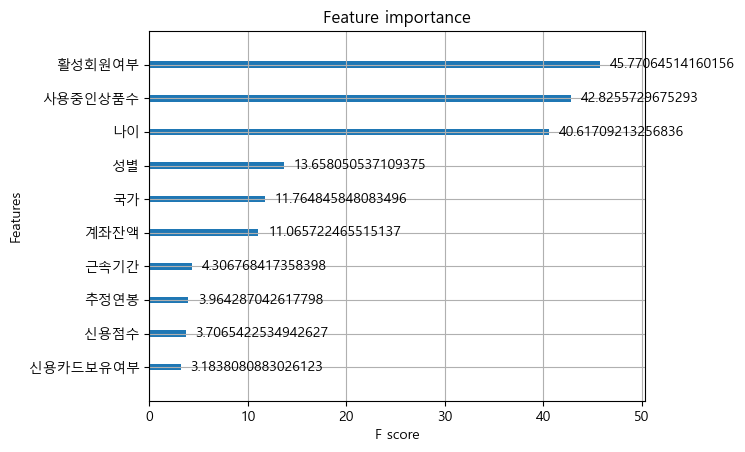

In [32]:
import xgboost as xgb
from sklearn.metrics import accuracy_score

# XGBoost 모델 초기화 및 학습
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
xgb_model.fit(X_train, y_train)

# 예측
y_pred_xgb = xgb_model.predict(X_test)

# 정확도 출력
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost 모델의 정확도: {accuracy_xgb:.2f}")

# 피처 중요도 시각화
xgb.plot_importance(xgb_model, importance_type='gain')
plt.show()

In [14]:
# 평가
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall", recall_score(y_test, y_pred_xgb))
print("f1_score", f1_score(y_test, y_pred_xgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("Classification Report:\n", classification_report(y_test, y_pred_xgb))

Accuracy: 0.868
Precision: 0.774468085106383
Recall 0.4631043256997455
f1_score 0.5796178343949043
Confusion Matrix:
 [[1554   53]
 [ 211  182]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.77      0.46      0.58       393

    accuracy                           0.87      2000
   macro avg       0.83      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000



### 4. LGBM

[LightGBM] [Info] Number of positive: 1644, number of negative: 6356
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000084 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 856
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.205500 -> initscore=-1.352267
[LightGBM] [Info] Start training from score -1.352267
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

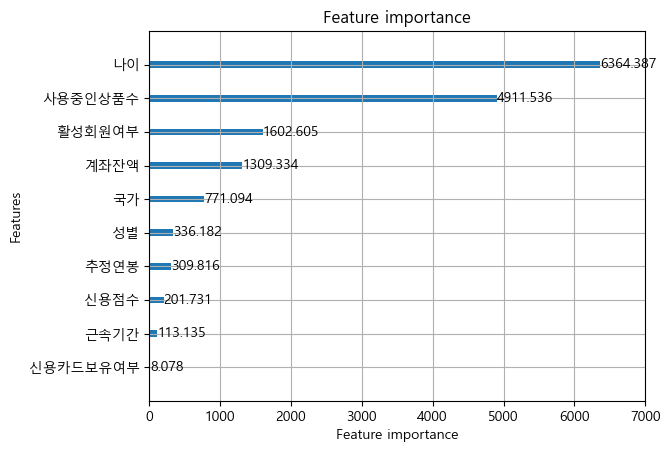

In [31]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score

# LightGBM 모델 초기화 및 학습
lgb_model = lgb.LGBMClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
lgb_model.fit(X_train, y_train)

# 예측
y_pred_lgb = lgb_model.predict(X_test)

# 정확도 출력
accuracy_lgb = accuracy_score(y_test, y_pred_lgb)
print(f"LightGBM 모델의 정확도: {accuracy_lgb:.2f}")

# 피처 중요도 시각화
lgb.plot_importance(lgb_model,importance_type='gain')
plt.show()


In [16]:
# 평가
print("Accuracy:", accuracy_score(y_test, y_pred_lgb))
print("Precision:", precision_score(y_test, y_pred_lgb))
print("Recall", recall_score(y_test, y_pred_lgb))
print("f1_score", f1_score(y_test, y_pred_lgb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lgb))
print("Classification Report:\n", classification_report(y_test, y_pred_lgb))

Accuracy: 0.8665
Precision: 0.7625
Recall 0.46564885496183206
f1_score 0.5781990521327014
Confusion Matrix:
 [[1550   57]
 [ 210  183]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.76      0.47      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000



### 5. CatBoost

CatBoost 모델의 정확도: 0.86
Feature importances: [ 0.73078698  8.8928082   2.73444584 31.74311362  0.43762595  8.57832756
 35.38978648  0.04235586 10.8215075   0.629242  ]


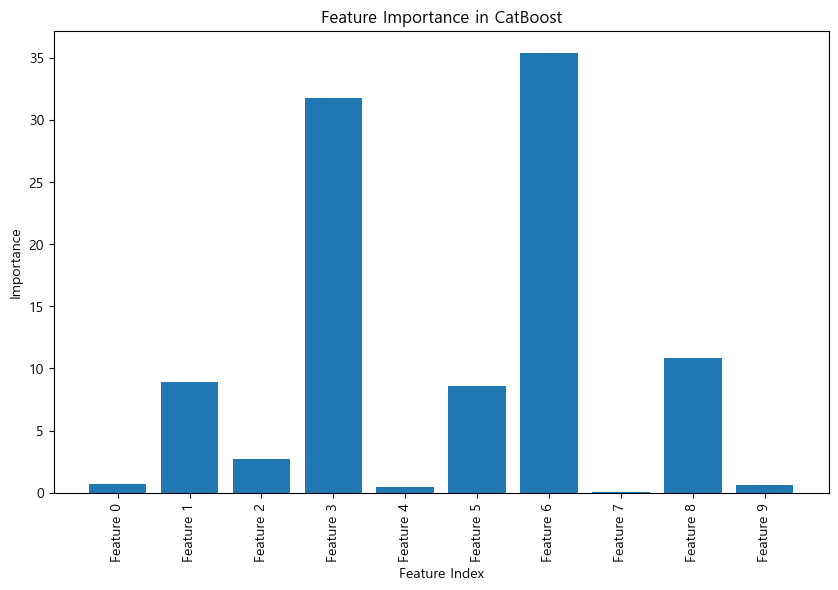

In [17]:
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# CatBoost 모델 초기화 및 학습
cat_model = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=3, random_state=42, verbose=0)
cat_model.fit(X_train, y_train)

# 예측
y_pred_cat = cat_model.predict(X_test)

# 정확도 출력
accuracy_cat = accuracy_score(y_test, y_pred_cat)
print(f"CatBoost 모델의 정확도: {accuracy_cat:.2f}")

# 피처 중요도 계산
feature_importances = cat_model.get_feature_importance(Pool(X_train, y_train))
print("Feature importances:", feature_importances)

# 피처 중요도 시각화
plt.figure(figsize=(10, 6))
plt.bar(range(X_train.shape[1]), feature_importances, align='center')
plt.xticks(np.arange(X_train.shape[1]), [f'Feature {i}' for i in range(X_train.shape[1])], rotation=90)
plt.xlabel('Feature Index')
plt.ylabel('Importance')
plt.title('Feature Importance in CatBoost')
plt.show()


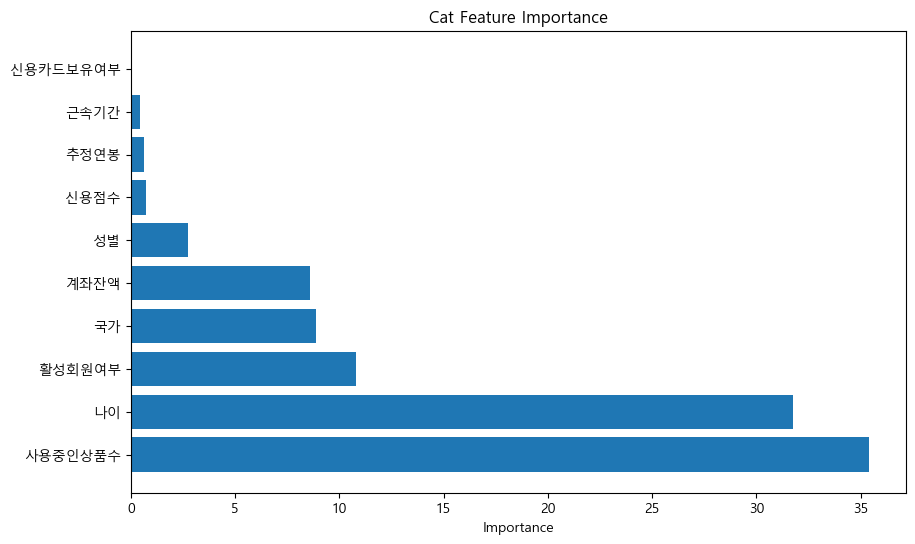

In [34]:
# 피처 중요도 출력
feature_importances = cat_model.feature_importances_
indices = np.argsort(feature_importances)[::-1]

# 특성 중요도 시각화
plt.figure(figsize=(10, 6))
plt.title('Cat Feature Importance')
plt.barh(range(X.shape[1]), feature_importances[indices], align='center')
plt.yticks(range(X.shape[1]), np.array(X.columns)[indices])
plt.xlabel('Importance')
plt.show()

In [18]:
# 평가
print("Accuracy:", accuracy_score(y_test, y_pred_cat))
print("Precision:", precision_score(y_test, y_pred_cat))
print("Recall", recall_score(y_test, y_pred_cat))
print("f1_score", f1_score(y_test, y_pred_cat))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_cat))
print("Classification Report:\n", classification_report(y_test, y_pred_cat))

Accuracy: 0.8615
Precision: 0.7478632478632479
Recall 0.44529262086513993
f1_score 0.5582137161084529
Confusion Matrix:
 [[1548   59]
 [ 218  175]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.45      0.56       393

    accuracy                           0.86      2000
   macro avg       0.81      0.70      0.74      2000
weighted avg       0.85      0.86      0.85      2000



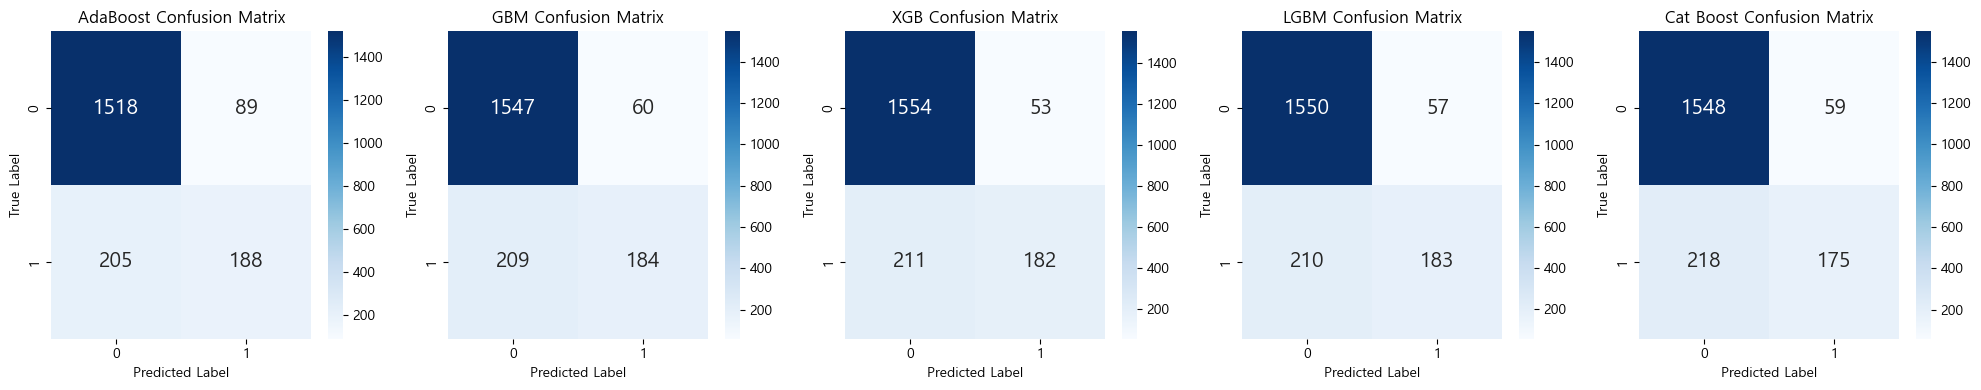

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 예시용 데이터 (다른 y_pred 값들을 미리 준비했다고 가정)
y_preds = [y_pred_ada, y_pred_gbm, y_pred_xgb, y_pred_lgb, y_pred_cat]  # 예측값 리스트
titles = ['AdaBoost', 'GBM', 'XGB', 'LGBM', 'Cat Boost']  # 각 subplot의 제목

# 5개의 서브플롯을 생성 (1행 5열)
fig, axs = plt.subplots(1, 5, figsize=(20, 4))

# 각 서브플롯에 혼동 행렬 시각화
for i, y_pred in enumerate(y_preds):
    matrix = confusion_matrix(y_test, y_pred)
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', ax=axs[i],annot_kws={"size": 15})
    axs[i].set_title(f'{titles[i]} Confusion Matrix')
    axs[i].set_xlabel('Predicted Label')
    axs[i].set_ylabel('True Label')

# 그래프 간 간격 조정
plt.tight_layout()
plt.show()


In [36]:
import xgboost as xgb
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification

# 데이터 생성
X, y = make_classification(n_samples=1000, n_features=20, n_informative=2, n_redundant=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# XGBoost 모델 학습
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42, eval_metric='auc')
xgb_model.fit(X_train, y_train)

# AUC 계산
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]  # 클래스 1의 확률
auc_score_xgb = roc_auc_score(y_test, y_pred_proba)
print(f"XGBoost 모델의 AUC: {auc_score_xgb:.2f}")

XGBoost 모델의 AUC: 0.93


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
import xgboost as xgb
import lightgbm as lgb
import catboost as cb
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# 데이터 생성
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 각 모델별 하이퍼파라미터 그리드 설정

# AdaBoost
ada_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1.0]
}

# XGBoost
xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# GradientBoosting (GMB)
gmb_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}

# LightGBM
lgbm_param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [-1, 3, 5],
    'num_leaves': [31, 50, 100],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# CatBoost
cat_param_grid = {
    'iterations': [200, 500],
    'learning_rate': [0.01, 0.1, 0.2],
    'depth': [3, 4, 5],
    'l2_leaf_reg': [1, 3, 5],
    'border_count': [32, 50, 100]
}

# 각 모델별로 GridSearchCV 적용

# AdaBoost
ada = AdaBoostClassifier()
ada_grid = GridSearchCV(estimator=ada, param_grid=ada_param_grid, cv=5, n_jobs=-1, verbose=2)
ada_grid.fit(X_train, y_train)
print("Best parameters for AdaBoost: ", ada_grid.best_params_)

# XGBoost
xgb_model = xgb.XGBClassifier()
xgb_grid = GridSearchCV(estimator=xgb_model, param_grid=xgb_param_grid, cv=5, n_jobs=-1, verbose=2)
xgb_grid.fit(X_train, y_train)
print("Best parameters for XGBoost: ", xgb_grid.best_params_)

# GradientBoosting
gmb = GradientBoostingClassifier()
gmb_grid = GridSearchCV(estimator=gmb, param_grid=gmb_param_grid, cv=5, n_jobs=-1, verbose=2)
gmb_grid.fit(X_train, y_train)
print("Best parameters for GradientBoosting: ", gmb_grid.best_params_)

# LightGBM
lgbm_model = lgb.LGBMClassifier()
lgbm_grid = GridSearchCV(estimator=lgbm_model, param_grid=lgbm_param_grid, cv=5, n_jobs=-1, verbose=2)
lgbm_grid.fit(X_train, y_train)
print("Best parameters for LightGBM: ", lgbm_grid.best_params_)

# CatBoost
cat_model = cb.CatBoostClassifier(verbose=0)
cat_grid = GridSearchCV(estimator=cat_model, param_grid=cat_param_grid, cv=5, n_jobs=-1, verbose=2)
cat_grid.fit(X_train, y_train)
print("Best parameters for CatBoost: ", cat_grid.best_params_)

# 최적의 모델로 성능 평가
best_models = {
    'AdaBoost': ada_grid.best_estimator_,
    'XGBoost': xgb_grid.best_estimator_,
    'GradientBoosting': gmb_grid.best_estimator_,
    'LightGBM': lgbm_grid.best_estimator_,
    'CatBoost': cat_grid.best_estimator_
}

for name, model in best_models.items():
    accuracy = model.score(X_test, y_test)
    print(f"{name} Test set accuracy: {accuracy:.4f}")
